# Model Selection and Hyperparameter Tuning

Cross-validation, GridSearchCV, RandomizedSearchCV, and why the search's
own best score is not an honest estimate of performance.

Dataset: Adult Income (same as notebook 02)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    KFold,
    GridSearchCV,
    RandomizedSearchCV,
    learning_curve
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

RANDOM_STATE = 42

In [2]:
data = fetch_openml("adult", version=2, as_frame=True)

X = data.data
y = (data.target == ">50K").astype(int)

print("Full dataset:", X.shape)
print("Positive class:", y.mean())

Full dataset: (48842, 14)
Positive class: 0.23928176569346055


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape)
print("Test: ", X_test.shape)

Train: (39073, 14)
Test:  (9769, 14)


In [4]:
X_tune, _, y_tune, _ = train_test_split(
    X_train,
    y_train,
    train_size=20000,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print("Tuning dataset:", X_tune.shape)
print("Tuning positive rate:", y_tune.mean())

Tuning dataset: (20000, 14)
Tuning positive rate: 0.23925


### Why use a 20,000-row tuning subset?

Hyperparameter search refits the model once per configuration per fold.
A search with multiple configurations and 3-fold CV requires many model
fits. To keep the search practical, tuning runs on a 20,000-row subsample
of the training data.

The final test evaluation still uses the full held-out test set, so the
reported test score is honest. However, the tuned model has seen less
training data than a production model would.

In [5]:
num_cols = X_tune.select_dtypes(include="number").columns.tolist()
cat_cols = X_tune.select_dtypes(exclude="number").columns.tolist()

preprocessor = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler())
        ]),
        num_cols
    ),
    (
        "cat",
        Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("encode", OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ))
        ]),
        cat_cols
    )
])

print("Numeric columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))

Numeric columns: 6
Categorical columns: 8


In [6]:
test_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

test_pipe.fit(X_tune, y_tune)

print("Pipeline fitted successfully.")
print("Predictions:", test_pipe.predict(X_tune.iloc[:5]))

Pipeline fitted successfully.
Predictions: [1 0 0 0 0]


In [7]:
cv3 = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_scores = cross_val_score(
    test_pipe,
    X_tune,
    y_tune,
    cv=cv3,
    scoring="roc_auc",
    n_jobs=-1
)

print("Fold scores:", cv_scores)
print(f"Mean ROC-AUC: {cv_scores.mean():.4f}")
print(f"Std ROC-AUC:  {cv_scores.std():.4f}")

Fold scores: [0.90019803 0.90397017 0.90700288]
Mean ROC-AUC: 0.9037
Std ROC-AUC:  0.0028


In [8]:
for n_folds in [3, 5, 10]:
    cv = StratifiedKFold(
        n_splits=n_folds,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    scores = cross_val_score(
        test_pipe,
        X_tune,
        y_tune,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    print(
        f"{n_folds}-fold CV: "
        f"mean={scores.mean():.4f}, "
        f"std={scores.std():.4f}"
    )

3-fold CV: mean=0.9037, std=0.0028
5-fold CV: mean=0.9045, std=0.0032
10-fold CV: mean=0.9043, std=0.0048


In [9]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

ordinary_scores = cross_val_score(
    test_pipe,
    X_tune,
    y_tune,
    cv=kf,
    scoring="roc_auc",
    n_jobs=-1
)

stratified_scores = cross_val_score(
    test_pipe,
    X_tune,
    y_tune,
    cv=skf,
    scoring="roc_auc",
    n_jobs=-1
)

print(
    f"KFold:           mean={ordinary_scores.mean():.4f}, "
    f"std={ordinary_scores.std():.4f}"
)

print(
    f"StratifiedKFold: mean={stratified_scores.mean():.4f}, "
    f"std={stratified_scores.std():.4f}"
)

KFold:           mean=0.9041, std=0.0073
StratifiedKFold: mean=0.9045, std=0.0032


## Cross-validation observations

Cross-validation gives several estimates instead of trusting one arbitrary
train/validation split. The fold-to-fold variation shows how much the score
can change depending on which observations are used for validation.

StratifiedKFold preserves the class balance in each fold, which is especially
appropriate for this imbalanced classification problem.

In [10]:
pipe = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l2"]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(X_tune, y_tune)

print("Best params:", grid.best_params_)
print(f"Best CV score: {grid.best_score_:.4f}")

/home/sid/machinelearning/ml-fundamentals/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/sid/machinelearning/ml-fundamentals/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warning

Best params: {'model__C': 0.1, 'model__penalty': 'l2'}
Best CV score: 0.9042


In [11]:
cv_df = pd.DataFrame(grid.cv_results_)[[
    "param_model__C",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score")

cv_df

,param_model__C,mean_test_score,std_test_score,rank_test_score
1,0.10,0.904198,0.003836,1
2,1.00,0.903765,0.003843,2
3,10.00,0.903120,0.003349,3
4,100.00,0.902913,0.003182,4
0,0.01,0.900209,0.003671,5


In [12]:
rf_pipe = Pipeline([
    ("prep", preprocessor),
    (
        "model",
        RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
])

In [13]:
param_dist = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

In [14]:
from math import prod

grid_size = prod(len(values) for values in param_dist.values())

print("Total possible combinations:", grid_size)
print("Random combinations we'll test:", 12)

Total possible combinations: 144
Random combinations we'll test: 12


In [15]:
rand = RandomizedSearchCV(
    rf_pipe,
    param_distributions=param_dist,
    n_iter=12,
    cv=3,
    scoring="roc_auc",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rand.fit(X_tune, y_tune)

print("Best params:", rand.best_params_)
print(f"Best CV score: {rand.best_score_:.4f}")

Best params: {'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 20}
Best CV score: 0.9124


In [16]:
rf_cv_score = rand.best_score_

rf_test_score = roc_auc_score(
    y_test,
    rand.best_estimator_.predict_proba(X_test)[:, 1]
)

print(f"Random Forest CV best score: {rf_cv_score:.4f}")
print(f"Random Forest test score:     {rf_test_score:.4f}")
print(f"Optimism:                     {rf_cv_score - rf_test_score:.4f}")

Random Forest CV best score: 0.9124
Random Forest test score:     0.9135
Optimism:                     -0.0011


In [17]:
log_cv_score = grid.best_score_

log_test_score = roc_auc_score(
    y_test,
    grid.best_estimator_.predict_proba(X_test)[:, 1]
)

print(f"Logistic Regression CV best score: {log_cv_score:.4f}")
print(f"Logistic Regression test score:     {log_test_score:.4f}")
print(f"Optimism:                            {log_cv_score - log_test_score:.4f}")

Logistic Regression CV best score: 0.9042
Logistic Regression test score:     0.9038
Optimism:                            0.0004


In [18]:
print(f"Notebook 02 untuned RF: {0.9061:.4f}")
print(f"Notebook 04 tuned RF:   {rf_test_score:.4f}")
print(f"Difference:             {rf_test_score - 0.9061:.4f}")

Notebook 02 untuned RF: 0.9061
Notebook 04 tuned RF:   0.9135
Difference:             0.0074


In [19]:
grid_results = pd.DataFrame(grid.cv_results_)

grid_results.to_csv(
    "../reports/tuning_results.csv",
    index=False
)

print("Saved tuning results.")

Saved tuning results.


In [34]:
summary = pd.DataFrame([
    {
        "model": "Tuned Logistic Regression",
        "cv_auc": log_cv_score,
        "test_auc": log_test_score,
        "cv_minus_test": log_cv_score - log_test_score
    },
    {
        "model": "Tuned Random Forest",
        "cv_auc": rand.best_score_,
        "test_auc": rf_test_score,
        "cv_minus_test": rand.best_score_ - rf_test_score
    }
])

summary

,model,cv_auc,test_auc,cv_minus_test
0,Tuned Logistic Regression,0.904198,0.903828,0.000370
1,Tuned Random Forest,0.912386,0.913462,-0.001077


## Model selection observations

### Cross-validation

The 3-fold, 5-fold and 10-fold cross-validation estimates were all close
to 0.904 ROC-AUC. Increasing the number of folds therefore did not
substantially change the estimated performance, although it increased
computation time.

StratifiedKFold produced a similar mean to ordinary KFold but with lower
fold-to-fold variation. Because this is an imbalanced classification
problem, stratification is the safer default.

### GridSearchCV

The best Logistic Regression value was C=0.1 with a CV ROC-AUC of 0.9042.
However, C=1 achieved 0.9038, so the difference between the top settings
was very small relative to their fold-to-fold variation.

### RandomizedSearchCV

The Random Forest search tested 12 configurations out of 144 possible
combinations. The best configuration achieved a CV ROC-AUC of 0.9124.
Its held-out test ROC-AUC was 0.9135.

The test score was slightly higher than the CV score by about 0.0011.
This is normal sampling variation rather than evidence that the test set
was used incorrectly.

/home/sid/machinelearning/ml-fundamentals/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/sid/machinelearning/ml-fundamentals/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warning

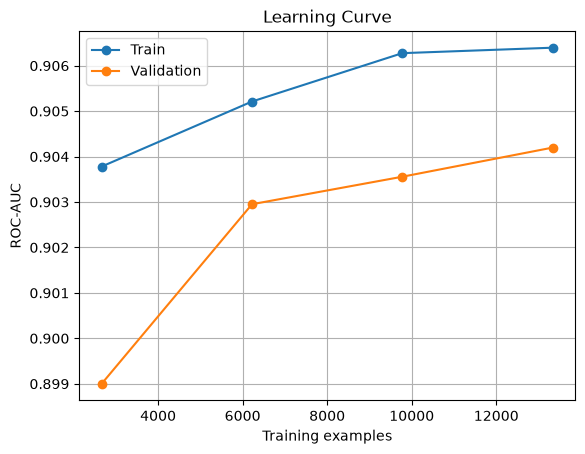

In [32]:
sizes, train_scores, val_scores = learning_curve(
    grid.best_estimator_,
    X_tune,
    y_tune,
    cv=3,
    scoring="roc_auc",
    train_sizes=np.linspace(0.2, 1.0, 4),
    n_jobs=-1
)

plt.plot(
    sizes,
    train_scores.mean(axis=1),
    marker="o",
    label="Train"
)

plt.plot(
    sizes,
    val_scores.mean(axis=1),
    marker="o",
    label="Validation"
)

plt.xlabel("Training examples")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve")
plt.legend()
plt.grid(True)

plt.savefig(
    "../reports/learning_curve.png",
    dpi=120,
    bbox_inches="tight"
)

plt.show()

### Learning curve interpretation

The training and validation ROC-AUC scores are close at larger training
sizes, with a gap of only about 0.002. This suggests that the model is not
strongly overfitting. The validation score is also still increasing at the
right edge of the curve rather than completely flattening out. This
suggests that additional training data could still provide some improvement,
although the gains may become smaller as the dataset grows.

# Conclusion

Cross-validation produced stable ROC-AUC estimates around 0.904 across
3, 5 and 10 folds. The similarity of the means suggests that the model's
estimated performance was not highly sensitive to the number of folds,
although more folds required more computation.

StratifiedKFold had a similar mean to ordinary KFold but lower
fold-to-fold variation (0.0032 vs 0.0073), making it the better choice
for this imbalanced classification problem.

GridSearchCV selected Logistic Regression with C=0.1, achieving a best
CV ROC-AUC of 0.9042. The difference from C=1 was very small, showing
that the exact value of C was not particularly important in this search.

RandomizedSearchCV tested 12 configurations out of 144 possible Random
Forest combinations. Its best configuration was:

- n_estimators = 100
- max_depth = 20
- min_samples_split = 2
- min_samples_leaf = 2
- max_features = "sqrt"

In this run the optimism did not appear — the test score came out 0.0011
higher than the CV score. That is within normal sampling variation, and it
does not disprove the bias. It means the bias here was smaller than the
noise, which is expected when only 12 configurations were tried. Searching
hundreds of configurations produces a much larger gap.

The tuned Random Forest reached a test ROC-AUC of 0.9135, compared with
0.9061 for the untuned forest in Notebook 02. This is not a clean
comparison: Notebook 02 trained on roughly 29,000 rows while this search
used a 20,000-row subsample for speed. The difference cannot be
attributed to tuning alone.

The important lesson is that the score reported by a search is not a
final unbiased performance estimate. The search uses the training data
repeatedly to select the best configuration, so the untouched test set
must remain separate until the final evaluation.